# Presentation Figures — xCPE-TimeDART

All 9 figures for the final presentation, covering architecture, training dynamics, embedding analysis, and results.  
Figures saved to `results/figures/`.

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})

LOGS_DIR     = Path('../results/logs')
FIGURES_DIR  = Path('../results/figures')
ETTH1_CSV    = Path('../results/tables/etth1_results.csv')
WEATHER_CSV  = Path('../results/tables/weather_results.csv')
RAW_ETTH1    = Path('../data/raw/data/raw/ETDataset/ETT-small/ETTh1.csv')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_etth1   = pd.read_csv(ETTH1_CSV)
df_weather = pd.read_csv(WEATHER_CSV)
DATASETS   = {'ETTh1': df_etth1, 'Weather': df_weather}

PALETTE = {
    'baseline':   '#4C72B0',
    'xcpe_all':   '#DD8452',
    'xcpe_early': '#55A868',
    'xcpe_late':  '#C44E52',
    'rope':       '#8172B2',
}
DISPLAY = {
    'baseline':   'Baseline',
    'xcpe_all':   'xCPE (all)',
    'xcpe_early': 'xCPE (early)',
    'xcpe_late':  'xCPE (late)',
    'rope':       'RoPE',
}
VARIANT_ORDER = ['baseline', 'xcpe_all', 'xcpe_early', 'xcpe_late', 'rope']
PATCH_LEN = 16
HORIZONS  = [96, 192, 336, 720]
print('Setup complete.')

Setup complete.


In [17]:
def load_log(path, phase='pretrain'):
    """Load a training log CSV, keeping only the first clean run.
    
    Logs may contain repeated runs due to multi-seed execution.
    We keep only the first monotonically-increasing step sequence.
    """
    df = pd.read_csv(path)
    df = df[df['step'] > 0].reset_index(drop=True)  # drop test rows (step==0)
    # Keep rows until step resets (first run only)
    cutoff = len(df)
    for i in range(1, len(df)):
        if df['step'].iloc[i] <= df['step'].iloc[i - 1]:
            cutoff = i
            break
    return df.iloc[:cutoff].reset_index(drop=True)

# Verify
pt = load_log(LOGS_DIR / 'ETTh1_h96_baseline_pretrain.csv')
ft = load_log(LOGS_DIR / 'ETTh1_h96_baseline_finetune.csv', 'finetune')
print(f'Pretrain epochs: {len(pt)}  |  Finetune epochs: {len(ft)}')
print(pt[['step','val_loss']].tail(3))

Pretrain epochs: 31  |  Finetune epochs: 12
    step  val_loss
28    29  0.149503
29    30  0.150046
30    31  0.145742


---
## Figure P1 — Patch Diagram
Real ETTh1 OT (oil temperature) segment with patch boundaries and forecast horizon.

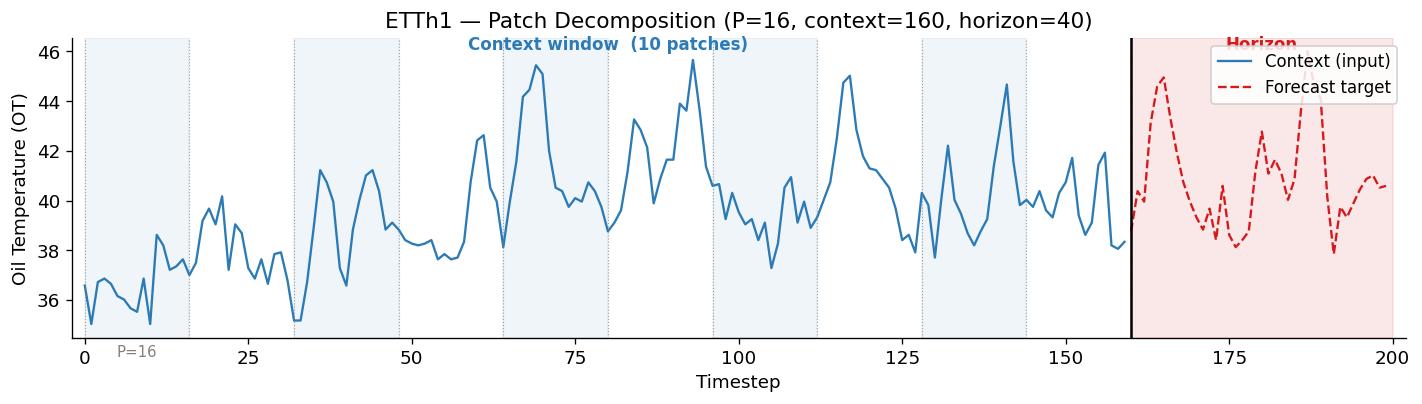

In [18]:
etth1 = pd.read_csv(RAW_ETTH1, parse_dates=['date'])
# Take a representative 200-step window from the training set
window = etth1['OT'].values[500:700]
t = np.arange(len(window))

fig, ax = plt.subplots(figsize=(12, 3.5))

# Context region (first 160 steps = 10 patches)
ctx_len = 160
horizon = 40
ax.plot(t[:ctx_len], window[:ctx_len], color='#2c7bb6', linewidth=1.4, label='Context (input)')
ax.plot(t[ctx_len:ctx_len+horizon], window[ctx_len:ctx_len+horizon],
        color='#d7191c', linewidth=1.4, linestyle='--', label='Forecast target')

# Patch boundaries
for i in range(0, ctx_len + 1, PATCH_LEN):
    ax.axvline(i, color='gray', linewidth=0.7, linestyle=':', alpha=0.7)

# Shade alternating patches for clarity
for p in range(ctx_len // PATCH_LEN):
    if p % 2 == 0:
        ax.axvspan(p * PATCH_LEN, (p + 1) * PATCH_LEN, alpha=0.07, color='#2c7bb6')

# Forecast region shading
ax.axvspan(ctx_len, ctx_len + horizon, alpha=0.10, color='#d7191c')
ax.axvline(ctx_len, color='black', linewidth=1.5, linestyle='-')

# Patch label
ax.annotate('', xy=(PATCH_LEN, window[:ctx_len].min() - 0.8),
            xytext=(0, window[:ctx_len].min() - 0.8),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
ax.text(PATCH_LEN / 2, window[:ctx_len].min() - 1.3, f'P={PATCH_LEN}',
        ha='center', fontsize=9, color='gray')

ax.text(ctx_len / 2, window[:ctx_len].max() + 0.4, 'Context window  (10 patches)',
        ha='center', fontsize=10, color='#2c7bb6', fontweight='bold')
ax.text(ctx_len + horizon / 2, window[:ctx_len].max() + 0.4, 'Horizon',
        ha='center', fontsize=10, color='#d7191c', fontweight='bold')

ax.set_xlabel('Timestep')
ax.set_ylabel('Oil Temperature (OT)')
ax.set_title('ETTh1 — Patch Decomposition (P=16, context=160, horizon=40)')
ax.legend(loc='upper right', framealpha=0.85)
ax.set_xlim(-2, ctx_len + horizon + 2)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP1_patch_diagram.png', bbox_inches='tight')
plt.show()

---
## Figure P2 — xCPE vs Fixed PE Schematic
Side-by-side diagram showing how each encoding works.

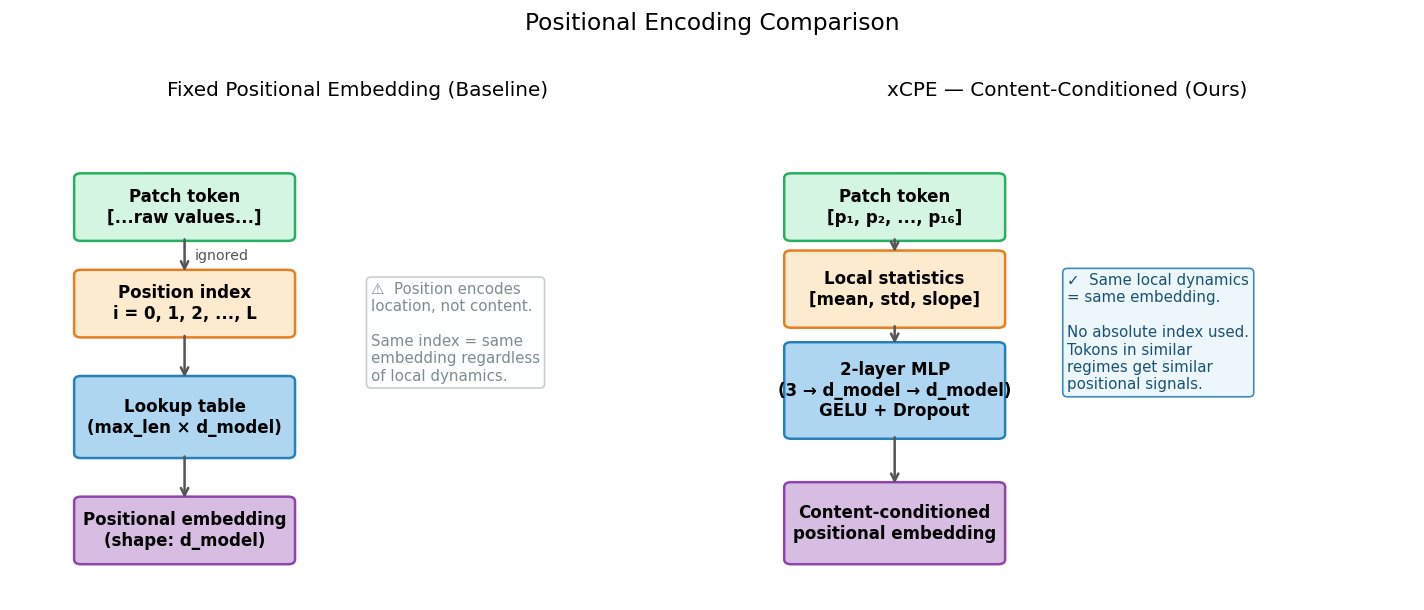

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left panel: Fixed PE ────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Fixed Positional Embedding (Baseline)', fontsize=12, pad=12)

def box(ax, x, y, w, h, text, fc='#AED6F1', ec='#2980B9', fontsize=10):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.1', facecolor=fc, edgecolor=ec, linewidth=1.5))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold')

def arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.15, my, label, fontsize=8.5, color=color, va='center')

# Fixed PE: patch → index → lookup → embedding
box(ax, 1, 7.5, 3, 1.2, 'Patch token\n[...raw values...]', fc='#D5F5E3', ec='#27AE60')
box(ax, 1, 5.5, 3, 1.2, 'Position index\ni = 0, 1, 2, ..., L', fc='#FDEBD0', ec='#E67E22')
box(ax, 1, 3.0, 3, 1.5, 'Lookup table\n(max_len × d_model)', fc='#AED6F1', ec='#2980B9')
box(ax, 1, 0.8, 3, 1.2, 'Positional embedding\n(shape: d_model)', fc='#D7BDE2', ec='#8E44AD')

arrow(ax, 2.5, 7.5, 2.5, 6.7, 'ignored')
arrow(ax, 2.5, 5.5, 2.5, 4.5)
arrow(ax, 2.5, 3.0, 2.5, 2.0)

ax.text(5.2, 5.5, '⚠  Position encodes\nlocation, not content.\n\nSame index = same\nembedding regardless\nof local dynamics.',
        fontsize=9, color='#7F8C8D', va='center',
        bbox=dict(boxstyle='round', fc='#FDFEFE', ec='#BDC3C7', alpha=0.8))

# ── Right panel: xCPE ───────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('xCPE — Content-Conditioned (Ours)', fontsize=12, pad=12)

box(ax, 1, 7.5, 3, 1.2, 'Patch token\n[p₁, p₂, ..., p₁₆]', fc='#D5F5E3', ec='#27AE60')
box(ax, 1, 5.7, 3, 1.4,
    'Local statistics\n[mean, std, slope]', fc='#FDEBD0', ec='#E67E22')
box(ax, 1, 3.4, 3, 1.8,
    '2-layer MLP\n(3 → d_model → d_model)\nGELU + Dropout', fc='#AED6F1', ec='#2980B9')
box(ax, 1, 0.8, 3, 1.5, 'Content-conditioned\npositional embedding', fc='#D7BDE2', ec='#8E44AD')

arrow(ax, 2.5, 7.5, 2.5, 7.1)
arrow(ax, 2.5, 5.7, 2.5, 5.2)
arrow(ax, 2.5, 3.4, 2.5, 2.3)

ax.text(5.0, 5.5, '✓  Same local dynamics\n= same embedding.\n\nNo absolute index used.\nTokons in similar\nregimes get similar\npositional signals.',
        fontsize=9, color='#1A5276', va='center',
        bbox=dict(boxstyle='round', fc='#EBF5FB', ec='#2980B9', alpha=0.9))

fig.suptitle('Positional Encoding Comparison', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP2_pe_schematic.png', bbox_inches='tight')
plt.show()

---
## Figure P3 — Pre-training Objective Illustration
DDPM-style patch corruption: ~50% of patches are noised, model predicts the noise.

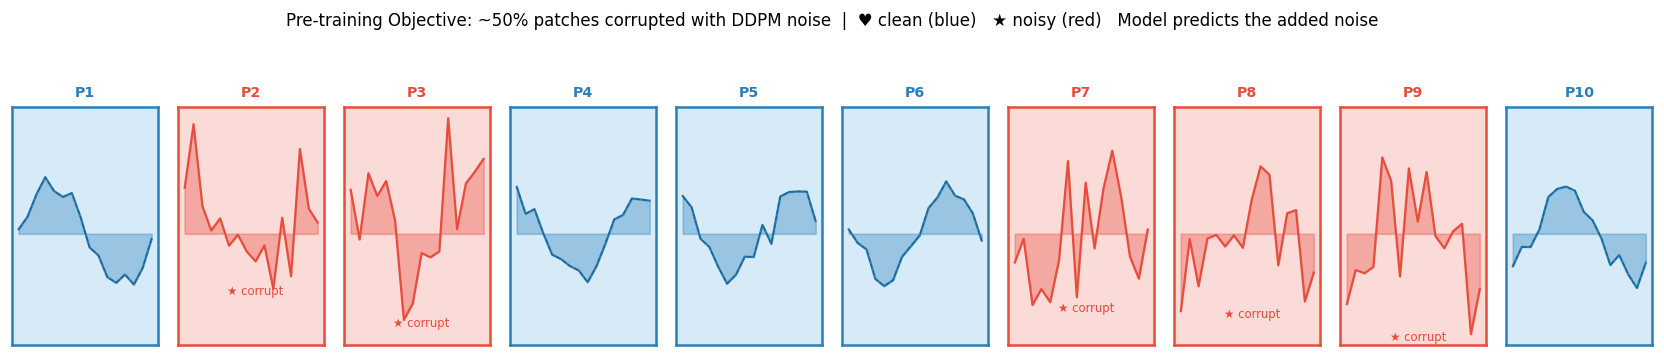

In [20]:
np.random.seed(42)
n_patches = 10
p_len = PATCH_LEN

# Simulate realistic ETTh1-like patches
raw_patches = []
t_base = np.linspace(0, 2 * np.pi, p_len)
for i in range(n_patches):
    base = np.sin(t_base + i * 0.6) + np.random.randn(p_len) * 0.2
    raw_patches.append(base)
raw_patches = np.array(raw_patches)

corrupted = np.random.choice(n_patches, size=n_patches // 2, replace=False)
noisy_patches = raw_patches.copy()
for idx in corrupted:
    noisy_patches[idx] += np.random.randn(p_len) * 0.8

fig, axes = plt.subplots(1, n_patches, figsize=(14, 2.8), sharey=True)

for i, ax in enumerate(axes):
    is_corrupt = i in corrupted
    color = '#E74C3C' if is_corrupt else '#2980B9'
    fc    = '#FADBD8' if is_corrupt else '#D6EAF8'
    ax.fill_between(range(p_len), noisy_patches[i], alpha=0.35, color=color)
    ax.plot(noisy_patches[i], color=color, linewidth=1.3)
    if not is_corrupt:
        ax.plot(raw_patches[i], color='#1A5276', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_facecolor(fc)
    ax.set_xticks([])
    ax.set_yticks([])
    lbl = f'P{i+1}'
    ax.set_title(lbl, fontsize=8.5, color=color, fontweight='bold')
    if is_corrupt:
        ax.text(p_len/2, noisy_patches[i].min() - 0.15, '\u2605 corrupt',
                ha='center', fontsize=7, color='#E74C3C')
    for sp in ax.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(1.5)

fig.suptitle(
    'Pre-training Objective: ~50% patches corrupted with DDPM noise  |  '
    '\u2665 clean (blue)   \u2605 noisy (red)   Model predicts the added noise',
    fontsize=10, y=1.05,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP3_pretrain_illustration.png', bbox_inches='tight')
plt.show()

---
## Figure P4 — Pre-training Loss Curves
Val loss over epochs for baseline vs xCPE (all) — H=96, seed 42.

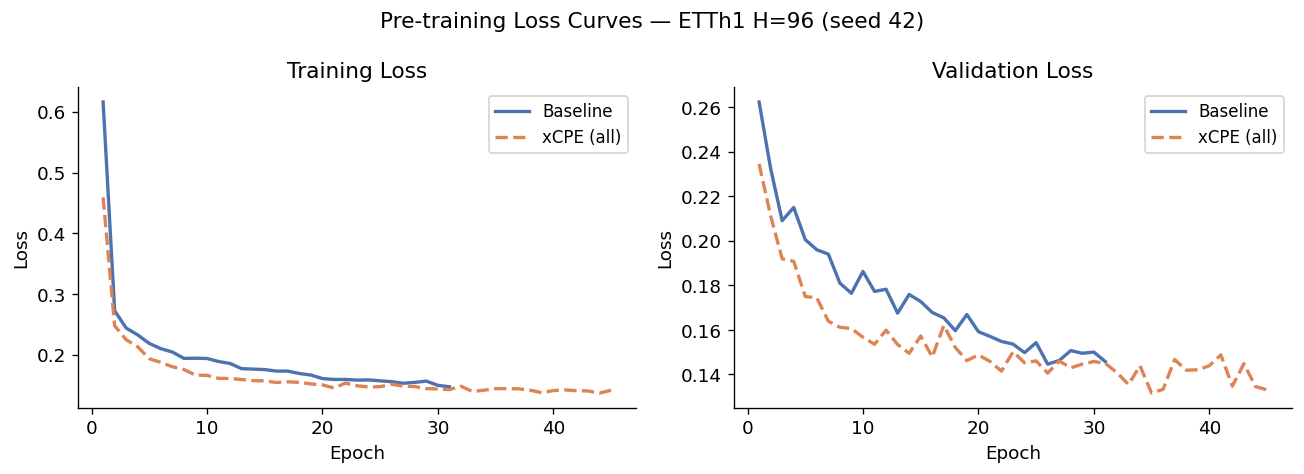

In [21]:
pt_base = load_log(LOGS_DIR / 'ETTh1_h96_baseline_pretrain.csv')
pt_xcpe = load_log(LOGS_DIR / 'ETTh1_h96_xcpe_all_pretrain.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, col, ylabel, title in zip(
    axes,
    ['train_loss', 'val_loss'],
    ['Loss', 'Loss'],
    ['Training Loss', 'Validation Loss'],
):
    ax.plot(pt_base['step'], pt_base[col],
            color=PALETTE['baseline'], linewidth=2, label=DISPLAY['baseline'])
    ax.plot(pt_xcpe['step'], pt_xcpe[col],
            color=PALETTE['xcpe_all'], linewidth=2, linestyle='--', label=DISPLAY['xcpe_all'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(framealpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Pre-training Loss Curves — ETTh1 H=96 (seed 42)', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP4_pretrain_curves.png', bbox_inches='tight')
plt.show()

---
## Figure P5 — Fine-tuning Learning Curves
Val MSE per epoch with encoder-unfreeze marker at epoch 5.

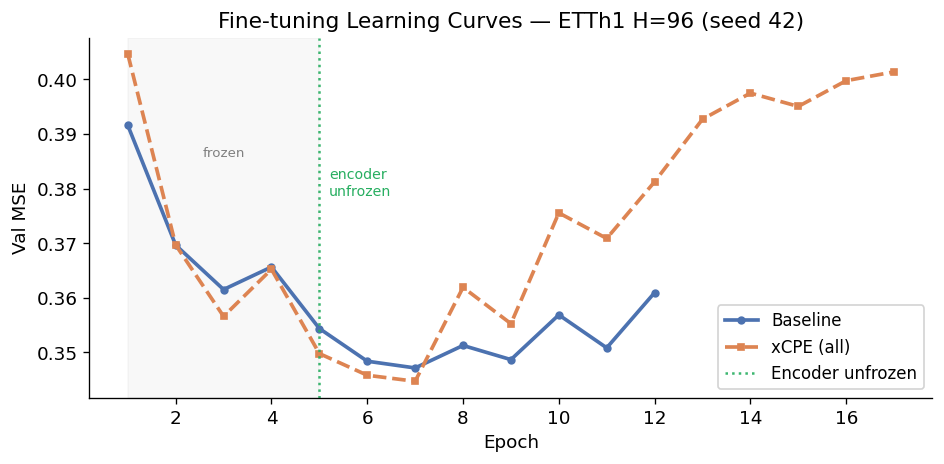

In [22]:
ft_base = load_log(LOGS_DIR / 'ETTh1_h96_baseline_finetune.csv', 'finetune')
ft_xcpe = load_log(LOGS_DIR / 'ETTh1_h96_xcpe_all_finetune.csv', 'finetune')

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ft_base['step'], ft_base['val_mse'],
        color=PALETTE['baseline'], linewidth=2.2, marker='o', markersize=4,
        label=DISPLAY['baseline'])
ax.plot(ft_xcpe['step'], ft_xcpe['val_mse'],
        color=PALETTE['xcpe_all'], linewidth=2.2, marker='s', markersize=4,
        linestyle='--', label=DISPLAY['xcpe_all'])

# Encoder unfreeze marker
ax.axvline(5, color='#27AE60', linewidth=1.5, linestyle=':', alpha=0.9, label='Encoder unfrozen')
ax.text(5.2, ft_base['val_mse'].max() * 0.98, 'encoder\nunfrozen',
        fontsize=8.5, color='#27AE60', va='top')

# Shade frozen region
ax.axvspan(1, 5, alpha=0.05, color='gray')
ax.text(3, ft_base['val_mse'].max() * 0.99, 'frozen', ha='center',
        fontsize=8, color='gray', va='top')

ax.set_xlabel('Epoch')
ax.set_ylabel('Val MSE')
ax.set_title('Fine-tuning Learning Curves — ETTh1 H=96 (seed 42)')
ax.legend(framealpha=0.85)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP5_finetune_curves.png', bbox_inches='tight')
plt.show()

---
## Figure P6 — Fixed PE Embedding Heatmap
Rows = patch positions (0 to L_ft), cols = d_model dimensions.  
Shows position-index-based structure (smooth, index-dependent patterns).

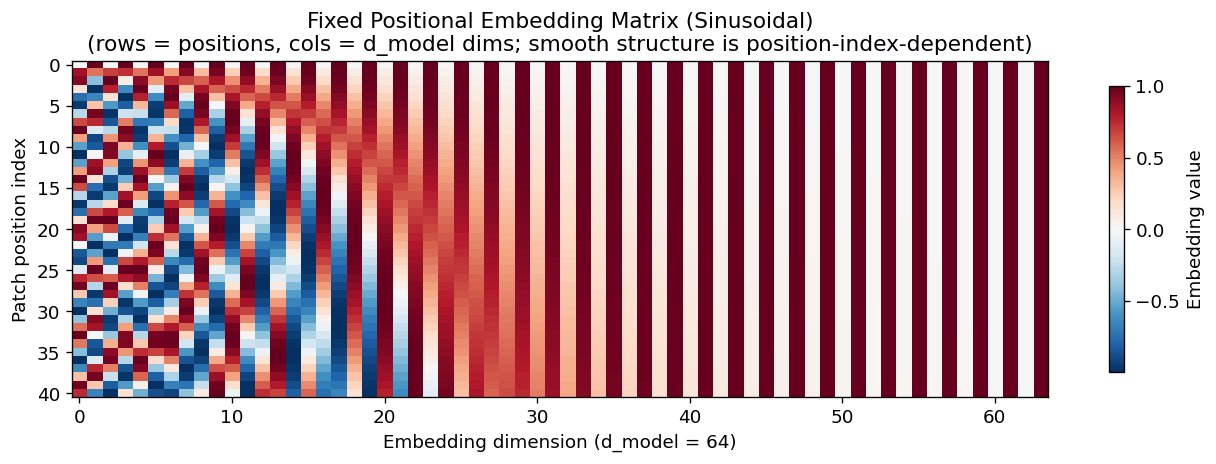

fixed_pe shape: (41, 64)  |  L_ft=41


In [23]:
d_model = 64
# L_ft = (336 - 16) // 8 + 1 = 41 patch positions at finetune stride=8
L_ft = (336 - 16) // 8 + 1

# Sinusoidal positional encoding (Vaswani et al., 2017) — no torch needed
positions = np.arange(L_ft)
dims      = np.arange(d_model)
div_term  = np.power(10000.0, (2 * (dims // 2) / d_model))
angles    = positions[:, np.newaxis] / div_term[np.newaxis, :]
fixed_pe  = np.zeros_like(angles)
fixed_pe[:, 0::2] = np.sin(angles[:, 0::2])
fixed_pe[:, 1::2] = np.cos(angles[:, 1::2])

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(fixed_pe, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, ax=ax, shrink=0.85, label='Embedding value')
ax.set_xlabel('Embedding dimension (d_model = 64)')
ax.set_ylabel('Patch position index')
ax.set_title('Fixed Positional Embedding Matrix (Sinusoidal)\n'
             '(rows = positions, cols = d_model dims; smooth structure is position-index-dependent)')
ax.set_yticks(range(0, L_ft, 5))

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP6_fixed_pe_heatmap.png', bbox_inches='tight')
plt.show()
print(f'fixed_pe shape: {fixed_pe.shape}  |  L_ft={L_ft}')

---
## Figure P7 — xCPE Conditioning Signal Distributions
Histograms of [mean, std, slope] computed from every 16-step patch in ETTh1 (OT column).  
These are the 3 scalars the xCPE MLP conditions on — shows they carry meaningful variation.

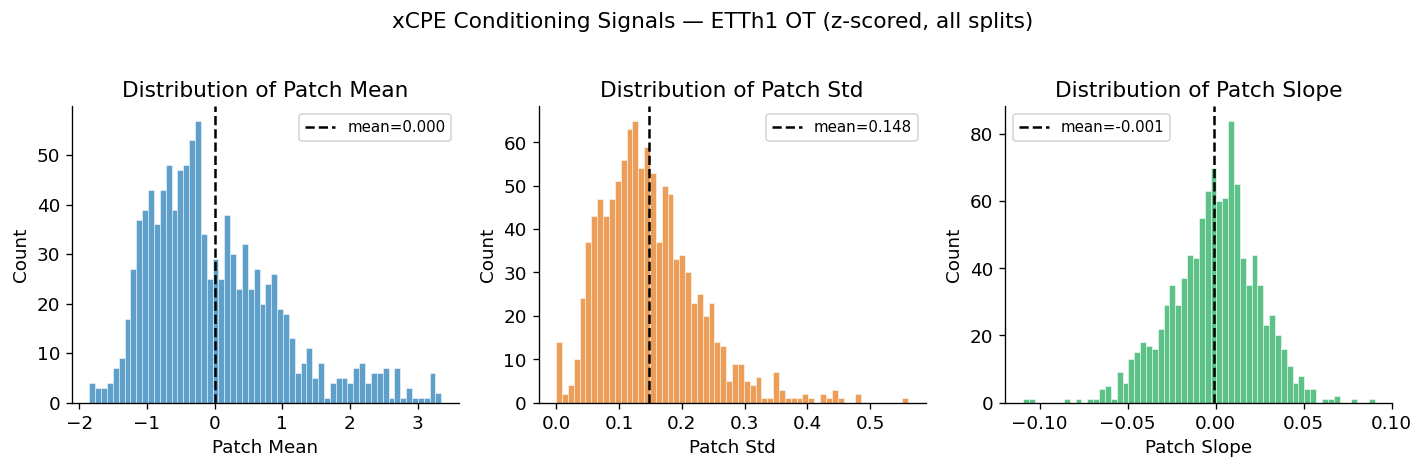

In [24]:
from sklearn.preprocessing import StandardScaler

ot = etth1['OT'].values
# z-score using train split (60% of 17420 rows)
n_train = int(len(ot) * 0.6)
scaler = StandardScaler()
ot_norm = scaler.fit_transform(ot.reshape(-1, 1)).flatten()

# Slide non-overlapping patches of length 16
means, stds, slopes = [], [], []
for start in range(0, len(ot_norm) - PATCH_LEN, PATCH_LEN):
    patch = ot_norm[start:start + PATCH_LEN]
    means.append(patch.mean())
    stds.append(patch.std())
    slopes.append((patch[-1] - patch[0]) / (PATCH_LEN - 1))

means  = np.array(means)
stds   = np.array(stds)
slopes = np.array(slopes)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
specs = [
    (means,  'Patch Mean',  '#2980B9'),
    (stds,   'Patch Std',   '#E67E22'),
    (slopes, 'Patch Slope', '#27AE60'),
]
for ax, (data, label, color) in zip(axes, specs):
    ax.hist(data, bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(np.mean(data), color='black', linewidth=1.5, linestyle='--',
               label=f'mean={np.mean(data):.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {label}')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('xCPE Conditioning Signals — ETTh1 OT (z-scored, all splits)',
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP7_xcpe_signal_distributions.png', bbox_inches='tight')
plt.show()

---
## Figure P8 — t-SNE of Positional Embeddings
**Left:** Fixed PE vectors colored by position index — clusters by index.  
**Right:** xCPE vectors (from ETTh1 patches) colored by local std — clusters by volatility regime.

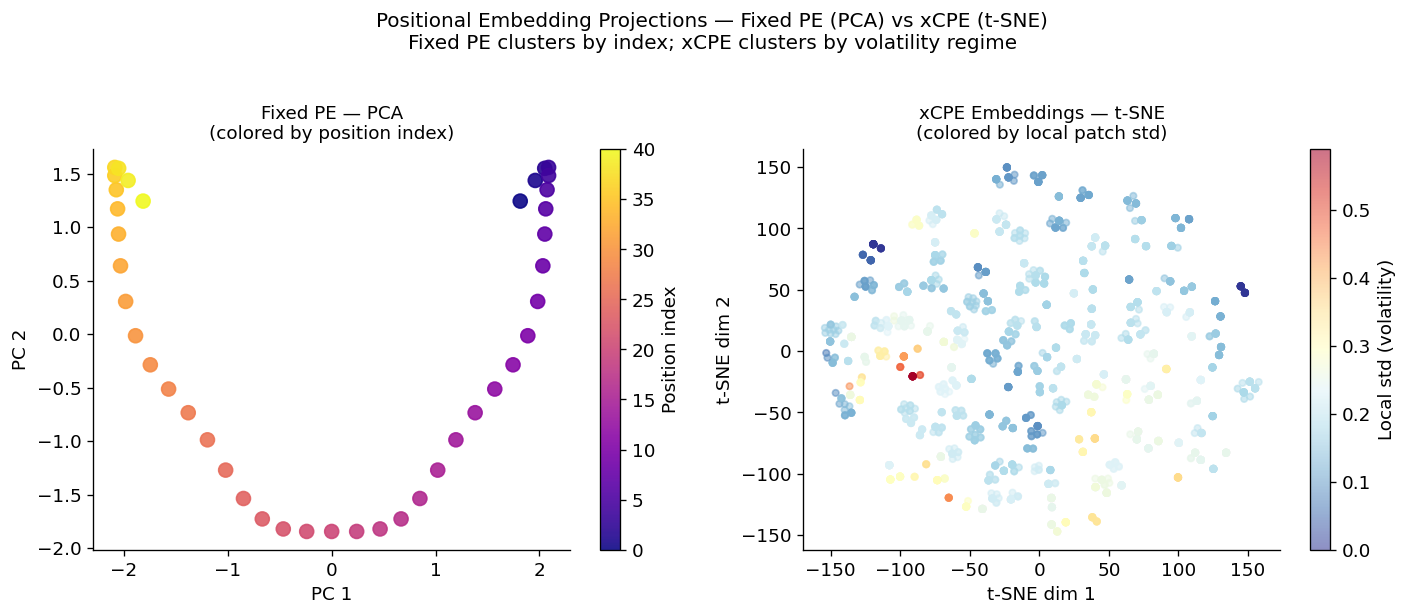

xCPE vectors: (2000, 64)  |  Fixed PE: (41, 64)


In [25]:
from sklearn.decomposition import PCA

np.random.seed(42)

# ── numpy GELU helper ────────────────────────────────────────────────────────
def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

# ── xCPE: 2-layer numpy MLP on [mean, std, slope] ───────────────────────────
rng = np.random.default_rng(42)
W1 = rng.standard_normal((3, d_model)) * np.sqrt(2 / 3)
b1 = np.zeros(d_model)
W2 = rng.standard_normal((d_model, d_model)) * np.sqrt(2 / d_model)
b2 = np.zeros(d_model)

def xcpe_numpy(features):
    """(N, 3) → (N, d_model)  — two-layer GELU MLP"""
    return gelu(features @ W1 + b1) @ W2 + b2

# Build [mean, std, slope] features from real ETTh1 patches (finetune stride=8)
stride = 8
ctx    = 336
patch_features = []
patch_stds_viz = []

for start in range(0, n_train - ctx, stride * 4):
    win = ot_norm[start:start + ctx]
    if len(win) < ctx:
        break
    for i in range(0, ctx - PATCH_LEN + 1, stride):
        patch = win[i:i + PATCH_LEN]
        slope = (patch[-1] - patch[0]) / (PATCH_LEN - 1)
        patch_features.append([patch.mean(), patch.std(), slope])
        patch_stds_viz.append(patch.std())

patch_features = np.array(patch_features[:2000])
patch_stds_viz = np.array(patch_stds_viz[:2000])

xcpe_vecs = xcpe_numpy(patch_features)              # (N, d_model)

# ── Fixed PE: PCA (only L_ft=41 points — t-SNE unreliable at this scale) ────
pca = PCA(n_components=2, random_state=42)
fixed_2d = pca.fit_transform(fixed_pe)              # (L_ft, 2)

# ── xCPE: t-SNE (max_iter replaces n_iter in sklearn ≥ 1.2) ─────────────────
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
xcpe_2d = tsne.fit_transform(xcpe_vecs)             # (N, 2)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(fixed_2d[:, 0], fixed_2d[:, 1],
                      c=np.arange(L_ft), cmap='plasma', s=70, alpha=0.9)
plt.colorbar(sc1, ax=axes[0], label='Position index')
axes[0].set_title('Fixed PE — PCA\n(colored by position index)', fontsize=11)
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].spines[['top', 'right']].set_visible(False)

sc2 = axes[1].scatter(xcpe_2d[:, 0], xcpe_2d[:, 1],
                      c=patch_stds_viz, cmap='RdYlBu_r', s=15, alpha=0.55)
plt.colorbar(sc2, ax=axes[1], label='Local std (volatility)')
axes[1].set_title('xCPE Embeddings — t-SNE\n(colored by local patch std)', fontsize=11)
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Positional Embedding Projections — Fixed PE (PCA) vs xCPE (t-SNE)\n'
             'Fixed PE clusters by index; xCPE clusters by volatility regime',
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP8_tsne_embeddings.png', bbox_inches='tight')
plt.show()
print(f'xCPE vectors: {xcpe_vecs.shape}  |  Fixed PE: {fixed_pe.shape}')

---
## Figure P9 — Win-Rate Summary Table
For each variant: how many of the 4 horizons does it beat the baseline on MSE?

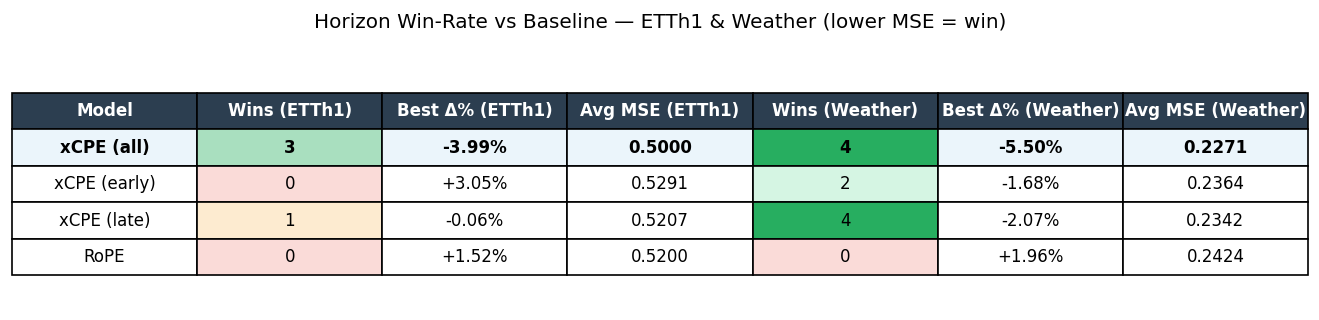

,Model,Wins (ETTh1),Best Δ% (ETTh1),Avg MSE (ETTh1),Wins (Weather),Best Δ% (Weather),Avg MSE (Weather)
0,xCPE (all),3,-3.99%,0.5000,4,-5.50%,0.2271
1,xCPE (early),0,+3.05%,0.5291,2,-1.68%,0.2364
2,xCPE (late),1,-0.06%,0.5207,4,-2.07%,0.2342
3,RoPE,0,+1.52%,0.5200,0,+1.96%,0.2424


In [26]:
def build_winrate(results_df):
    base = results_df[results_df['variant'] == 'baseline'].set_index('horizon')['mse_mean']
    rows = []
    for variant in VARIANT_ORDER:
        if variant == 'baseline':
            continue
        vdf = results_df[results_df['variant'] == variant].set_index('horizon')
        wins      = sum(vdf.loc[h, 'mse_mean'] < base[h] for h in HORIZONS)
        best_pct  = min((vdf.loc[h, 'mse_mean'] - base[h]) / base[h] * 100 for h in HORIZONS)
        avg_mse   = vdf['mse_mean'].mean()
        rows.append({'Model': DISPLAY[variant], 'Wins': wins,
                     'Best Δ%': f'{best_pct:+.2f}%', 'Avg MSE': f'{avg_mse:.4f}'})
    return pd.DataFrame(rows)

wr_e = build_winrate(df_etth1)
wr_w = build_winrate(df_weather)
combined = wr_e.merge(wr_w, on='Model', suffixes=(' (ETTh1)', ' (Weather)'))

col_labels = combined.columns.tolist()
cell_data  = combined.values.tolist()

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis('off')
tbl = ax.table(cellText=cell_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 1.9)

for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#2C3E50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

win_colors = {0: '#FADBD8', 1: '#FDEBD0', 2: '#D5F5E3', 3: '#A9DFBF', 4: '#27AE60'}
wins_cols  = [j for j, c in enumerate(col_labels) if c.startswith('Wins')]

for i, row in enumerate(cell_data):
    for j in wins_cols:
        tbl[(i+1, j)].set_facecolor(win_colors.get(row[j], 'white'))
    if 'xCPE (all)' in row[0]:
        for j in range(len(col_labels)):
            tbl[(i+1, j)].set_facecolor('#EBF5FB')
            tbl[(i+1, j)].set_text_props(fontweight='bold')
        for j in wins_cols:
            tbl[(i+1, j)].set_facecolor(win_colors.get(row[j], 'white'))

ax.set_title('Horizon Win-Rate vs Baseline — ETTh1 & Weather (lower MSE = win)',
             fontsize=12, pad=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP9_winrate_table.png', bbox_inches='tight', dpi=150)
plt.show()
combined

---
## Figure P10 — Cross-Dataset Gain Scaling (key narrative figure)
xCPE improvement % vs horizon for both datasets on the same axes.  
Shows: gains grow with horizon length; consistently larger on Weather (non-stationary) than ETTh1 (periodic).

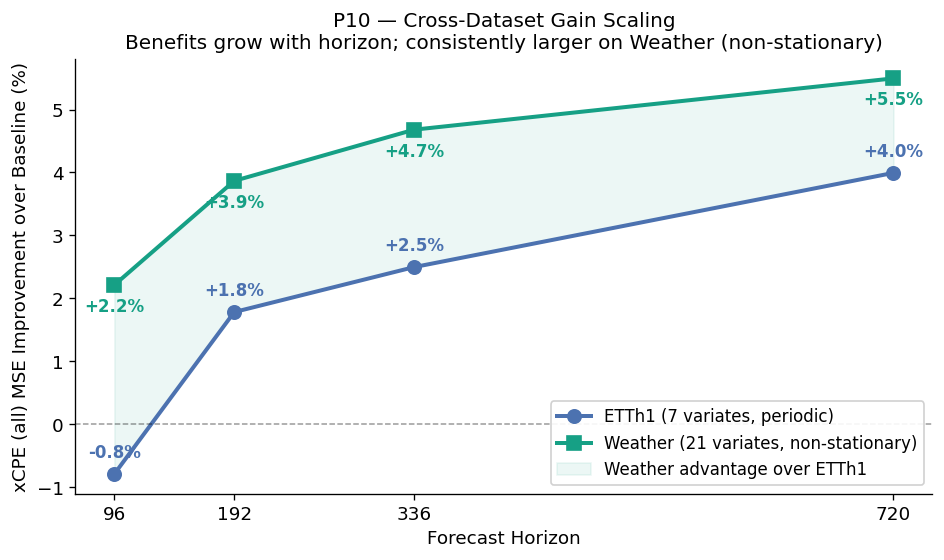

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.8))

COLOR_ETTH1   = PALETTE['baseline']   # blue
COLOR_WEATHER = '#16A085'             # teal

base_e = df_etth1[df_etth1['variant']=='baseline'].set_index('horizon')['mse_mean']
xcpe_e = df_etth1[df_etth1['variant']=='xcpe_all'].set_index('horizon')['mse_mean']
gain_etth1 = [(base_e[h] - xcpe_e[h]) / base_e[h] * 100 for h in HORIZONS]

base_w = df_weather[df_weather['variant']=='baseline'].set_index('horizon')['mse_mean']
xcpe_w = df_weather[df_weather['variant']=='xcpe_all'].set_index('horizon')['mse_mean']
gain_weather = [(base_w[h] - xcpe_w[h]) / base_w[h] * 100 for h in HORIZONS]

ax.plot(HORIZONS, gain_etth1, marker='o', markersize=8, linewidth=2.4,
        color=COLOR_ETTH1, label='ETTh1 (7 variates, periodic)')
ax.plot(HORIZONS, gain_weather, marker='s', markersize=8, linewidth=2.4,
        color=COLOR_WEATHER, label='Weather (21 variates, non-stationary)')

for h, g in zip(HORIZONS, gain_etth1):
    ax.annotate(f'{g:+.1f}%', xy=(h, g), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=10,
                color=COLOR_ETTH1, fontweight='bold')
for h, g in zip(HORIZONS, gain_weather):
    ax.annotate(f'{g:+.1f}%', xy=(h, g), xytext=(0, -16),
                textcoords='offset points', ha='center', fontsize=10,
                color=COLOR_WEATHER, fontweight='bold')

ax.fill_between(HORIZONS, gain_weather, gain_etth1,
                alpha=0.08, color=COLOR_WEATHER, label='Weather advantage over ETTh1')
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.4)

ax.set_xticks(HORIZONS)
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('xCPE (all) MSE Improvement over Baseline (%)')
ax.set_title('P10 — Cross-Dataset Gain Scaling\n'
             'Benefits grow with horizon; consistently larger on Weather (non-stationary)',
             fontsize=12)
ax.legend(framealpha=0.9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP10_crossdataset_gain_scaling.png', bbox_inches='tight')
plt.show()

---
## Figure P11 — Dataset Characteristics Comparison
Side-by-side table: ETTh1 vs Weather — size, variates, frequency, splits, and context.

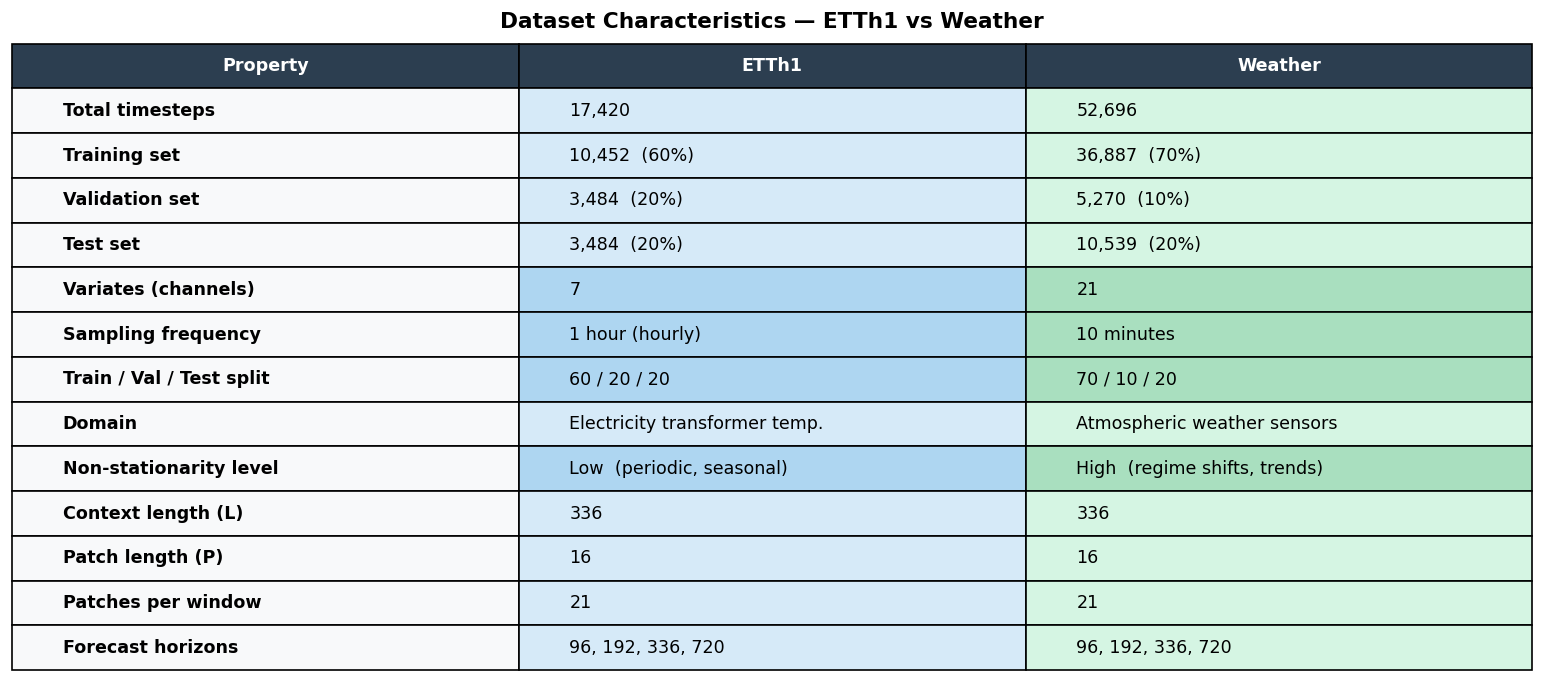

In [28]:
datasets_info = {
    'Property': [
        'Total timesteps', 'Training set', 'Validation set', 'Test set',
        'Variates (channels)', 'Sampling frequency', 'Train / Val / Test split',
        'Domain', 'Non-stationarity level',
        'Context length (L)', 'Patch length (P)', 'Patches per window',
        'Forecast horizons',
    ],
    'ETTh1': [
        '17,420', '10,452  (60%)', '3,484  (20%)', '3,484  (20%)',
        '7', '1 hour (hourly)', '60 / 20 / 20',
        'Electricity transformer temp.', 'Low  (periodic, seasonal)',
        '336', '16', '21',
        '96, 192, 336, 720',
    ],
    'Weather': [
        '52,696', '36,887  (70%)', '5,270  (10%)', '10,539  (20%)',
        '21', '10 minutes', '70 / 10 / 20',
        'Atmospheric weather sensors', 'High  (regime shifts, trends)',
        '336', '16', '21',
        '96, 192, 336, 720',
    ],
}

df_info = pd.DataFrame(datasets_info)
col_labels = df_info.columns.tolist()
cell_data  = df_info.values.tolist()

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.axis('off')
tbl = ax.table(cellText=cell_data, colLabels=col_labels, cellLoc='left', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
tbl.scale(1.0, 2.05)

for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#2C3E50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

HIGHLIGHT = {4, 5, 6, 8}   # variates, freq, split, non-stationarity
for i, _ in enumerate(cell_data):
    tbl[(i+1, 0)].set_facecolor('#F8F9FA')
    tbl[(i+1, 0)].set_text_props(fontweight='bold')
    tbl[(i+1, 1)].set_facecolor('#AED6F1' if i in HIGHLIGHT else '#D6EAF8')
    tbl[(i+1, 2)].set_facecolor('#A9DFBF' if i in HIGHLIGHT else '#D5F5E3')

ax.set_title('Dataset Characteristics — ETTh1 vs Weather', fontsize=13, pad=22, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP11_dataset_characteristics.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Cross-Dataset Results Comparison (P12 - P19)
All five model variants across ETTh1 and Weather: MSE, MAE, improvement heatmap, rankings.

### P12 — Test MSE at H=96 (side-by-side bar chart)

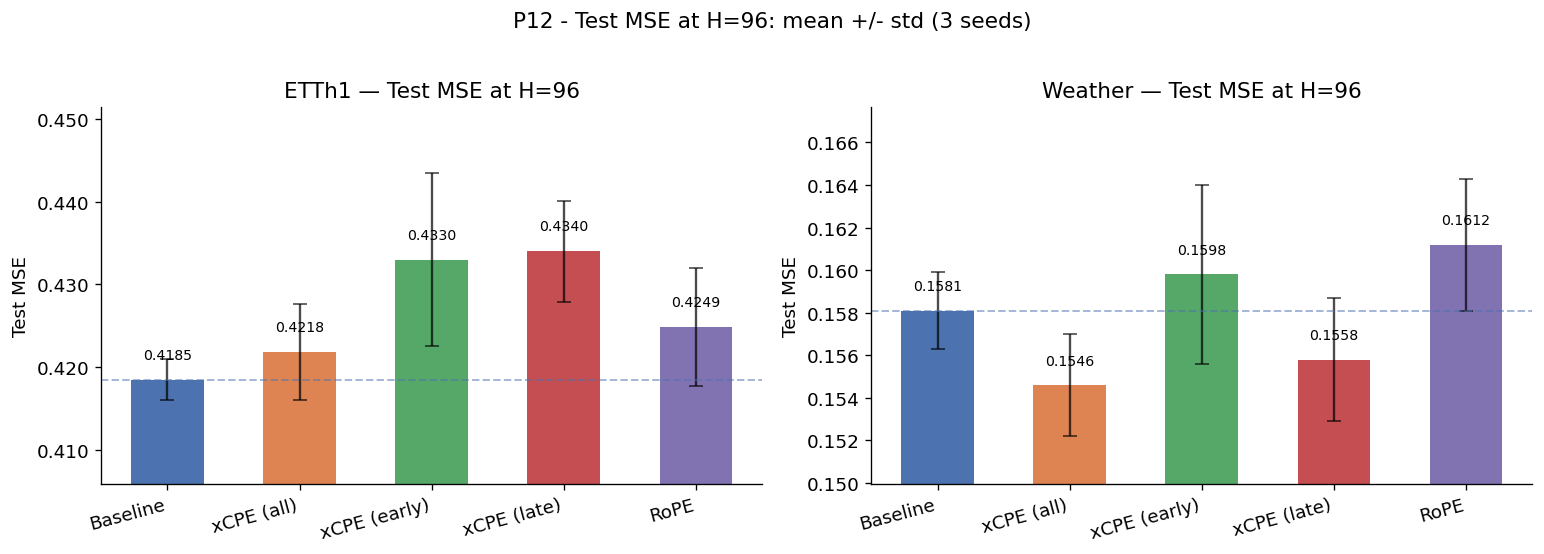

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (dset, df) in zip(axes, DATASETS.items()):
    h96  = df[df['horizon'] == 96].set_index('variant').reindex(VARIANT_ORDER)
    x    = np.arange(len(VARIANT_ORDER))
    bump = h96['mse_mean'].max() * 0.005
    bars = ax.bar(
        x, h96['mse_mean'], yerr=h96['mse_std'], capsize=4,
        color=[PALETTE[v] for v in VARIANT_ORDER], width=0.55,
        error_kw={'elinewidth': 1.4, 'ecolor': 'black', 'alpha': 0.7},
    )
    for bar, val in zip(bars, h96['mse_mean']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bump,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8.5)
    ax.axhline(h96.loc['baseline', 'mse_mean'], color=PALETTE['baseline'],
               linestyle='--', linewidth=1.2, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([DISPLAY[v] for v in VARIANT_ORDER], rotation=15, ha='right')
    ax.set_ylabel('Test MSE')
    ax.set_title(f'{dset} — Test MSE at H=96')
    ax.set_ylim(h96['mse_mean'].min() * 0.97, h96['mse_mean'].max() * 1.04)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('P12 - Test MSE at H=96: mean +/- std (3 seeds)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP12_bar_mse_h96.png', bbox_inches='tight')
plt.show()

### P13 — MSE vs Horizon: all variants, both datasets

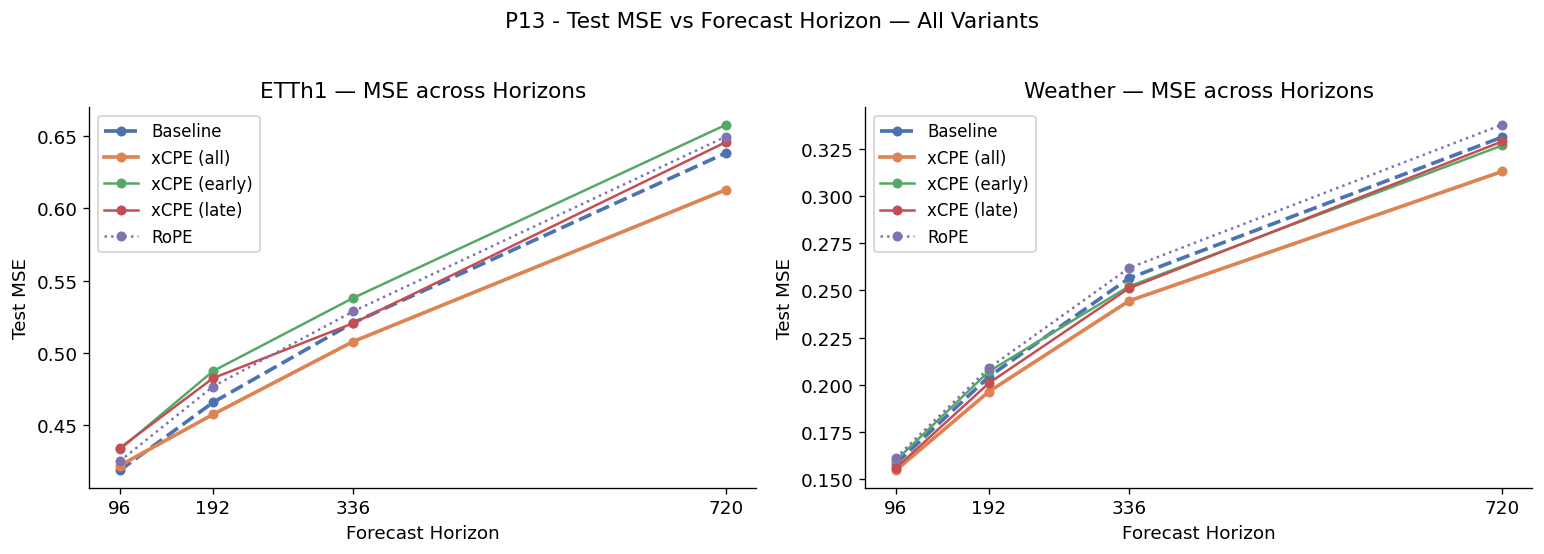

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, (dset, df) in zip(axes, DATASETS.items()):
    for variant in VARIANT_ORDER:
        vdf = df[df['variant'] == variant].sort_values('horizon')
        ls  = '-' if 'xcpe' in variant else ('--' if variant == 'baseline' else ':')
        lw  = 2.2 if variant in ('baseline', 'xcpe_all') else 1.5
        ax.plot(vdf['horizon'], vdf['mse_mean'],
                marker='o', markersize=5,
                color=PALETTE[variant], linestyle=ls, linewidth=lw,
                label=DISPLAY[variant])
    ax.set_xticks(HORIZONS)
    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel('Test MSE')
    ax.set_title(f'{dset} — MSE across Horizons')
    ax.legend(loc='upper left', framealpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('P13 - Test MSE vs Forecast Horizon — All Variants', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP13_line_mse_horizons.png', bbox_inches='tight')
plt.show()

### P14 — MSE mean +/- std per Variant x Horizon

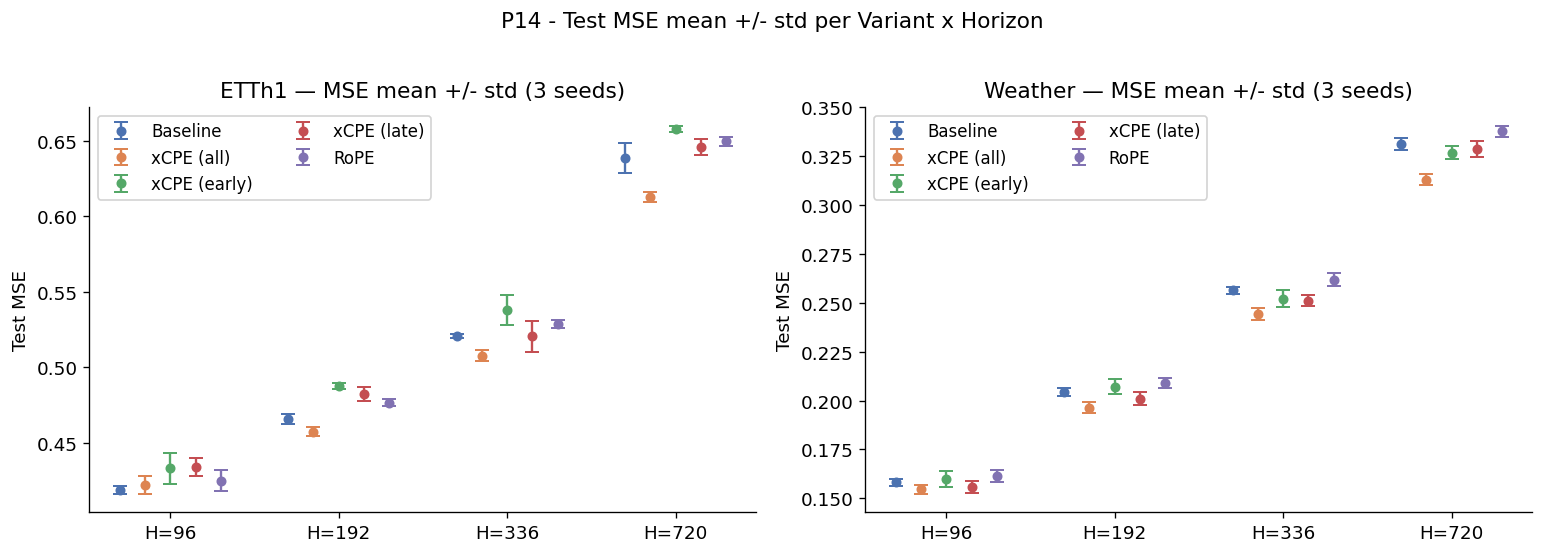

In [31]:
n_variants = len(VARIANT_ORDER)
width      = 0.15
offsets    = np.linspace(-(n_variants-1)/2, (n_variants-1)/2, n_variants) * width

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, (dset, df) in zip(axes, DATASETS.items()):
    x = np.arange(len(HORIZONS))
    for i, variant in enumerate(VARIANT_ORDER):
        vdf = df[df['variant'] == variant].sort_values('horizon')
        ax.errorbar(
            x + offsets[i], vdf['mse_mean'].values, yerr=vdf['mse_std'].values,
            fmt='o', markersize=5, color=PALETTE[variant],
            capsize=4, capthick=1.2, linewidth=1.4,
            label=DISPLAY[variant],
        )
    ax.set_xticks(x)
    ax.set_xticklabels([f'H={h}' for h in HORIZONS])
    ax.set_ylabel('Test MSE')
    ax.set_title(f'{dset} — MSE mean +/- std (3 seeds)')
    ax.legend(loc='upper left', framealpha=0.85, ncol=2)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('P14 - Test MSE mean +/- std per Variant x Horizon', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP14_errorbar_mse.png', bbox_inches='tight')
plt.show()

### P15 — Relative MSE Improvement vs Baseline
Negative % = improvement. Shared colorscale enables direct cross-dataset comparison.

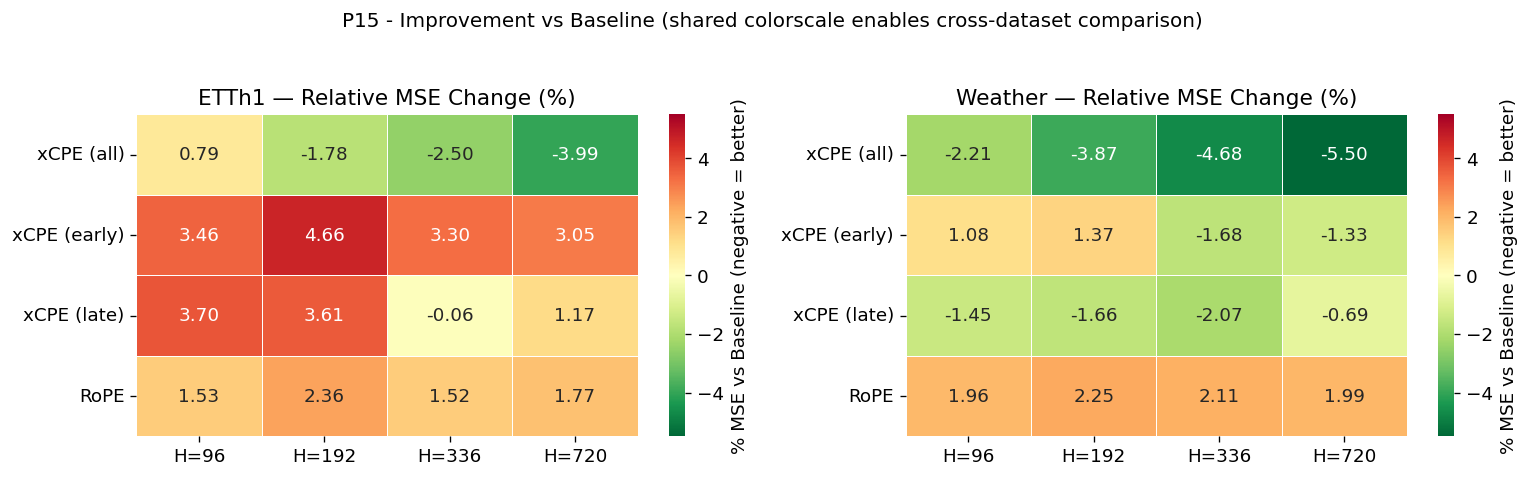

In [32]:
compare_variants = ['xcpe_all', 'xcpe_early', 'xcpe_late', 'rope']

def build_heatmap_df(df):
    base = df[df['variant'] == 'baseline'].set_index('horizon')['mse_mean']
    rows = []
    for v in compare_variants:
        vdf = df[df['variant'] == v].set_index('horizon')
        rows.append([(vdf.loc[h, 'mse_mean'] - base[h]) / base[h] * 100
                     for h in HORIZONS])
    return pd.DataFrame(rows,
                        index=[DISPLAY[v] for v in compare_variants],
                        columns=[f'H={h}' for h in HORIZONS])

hm_etth1   = build_heatmap_df(df_etth1)
hm_weather = build_heatmap_df(df_weather)
vabs = max(hm_etth1.abs().values.max(), hm_weather.abs().values.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

for ax, hm, dset in zip(axes, [hm_etth1, hm_weather], DATASETS.keys()):
    sns.heatmap(
        hm, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn_r',
        center=0, vmin=-vabs, vmax=vabs, linewidths=0.5,
        cbar_kws={'label': '% MSE vs Baseline (negative = better)'},
    )
    ax.set_title(f'{dset} — Relative MSE Change (%)')
    ax.set_ylabel('')

fig.suptitle('P15 - Improvement vs Baseline (shared colorscale enables cross-dataset comparison)',
             fontsize=12, y=1.04)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP15_improvement_heatmap.png', bbox_inches='tight')
plt.show()

### P16 — MSE and MAE at H=96 (ETTh1 top row, Weather bottom row)

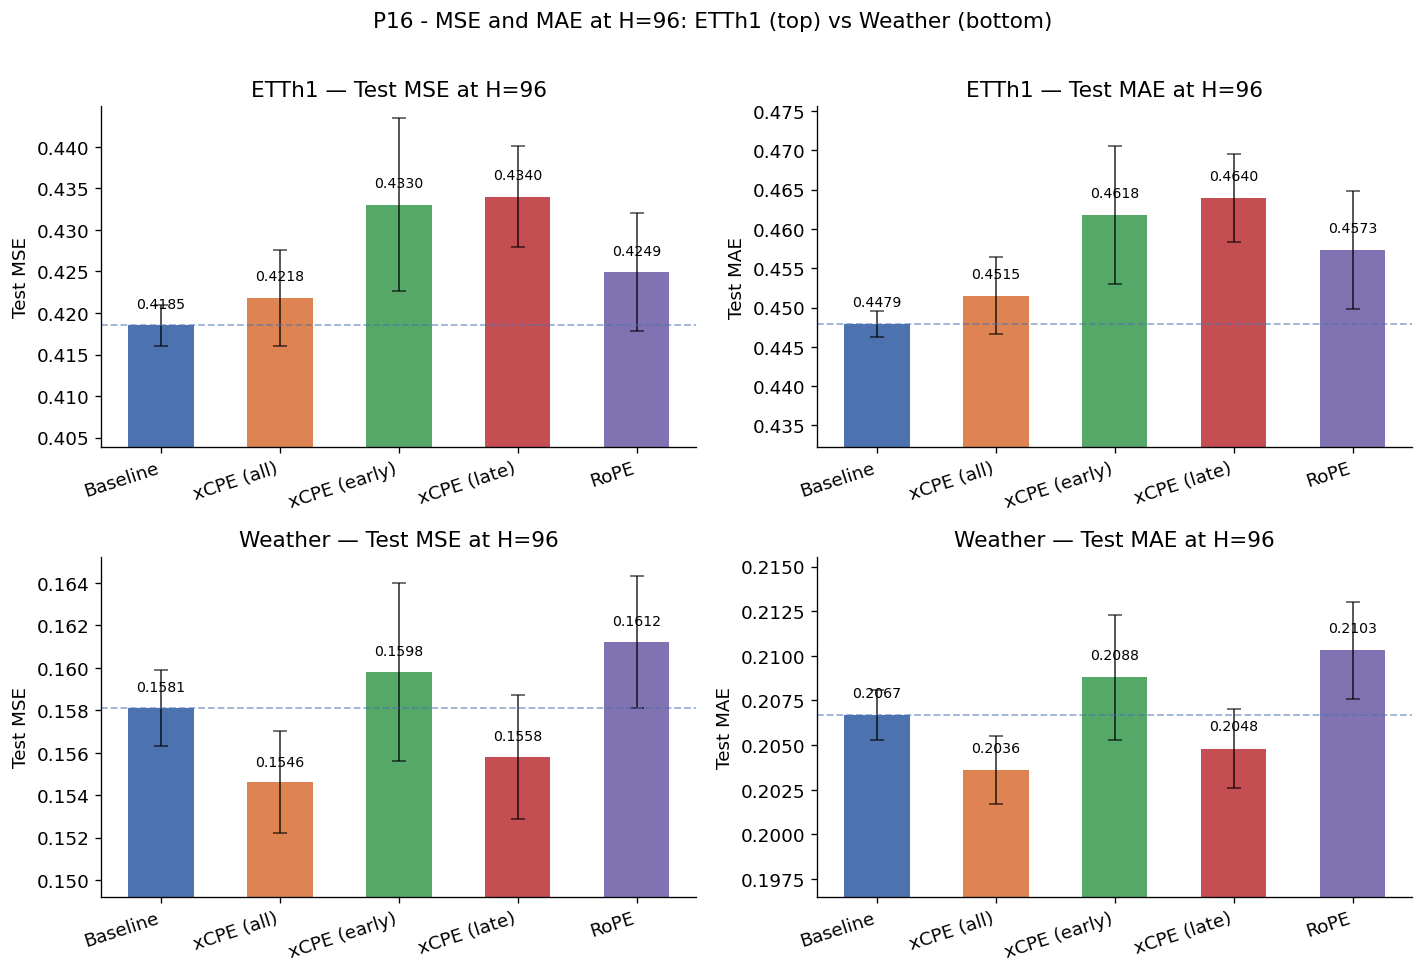

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x      = np.arange(len(VARIANT_ORDER))
colors = [PALETTE[v] for v in VARIANT_ORDER]

for row_i, (dset, df) in enumerate(DATASETS.items()):
    h96 = df[df['horizon'] == 96].set_index('variant').reindex(VARIANT_ORDER)
    for col_i, (metric, std_col, label) in enumerate([
        ('mse_mean', 'mse_std', 'Test MSE'),
        ('mae_mean', 'mae_std', 'Test MAE'),
    ]):
        ax   = axes[row_i, col_i]
        bump = h96[metric].max() * 0.004
        bars = ax.bar(x, h96[metric], yerr=h96[std_col], capsize=4,
                      color=colors, width=0.55,
                      error_kw={'elinewidth': 1.2, 'ecolor': 'black', 'alpha': 0.65})
        for bar, val in zip(bars, h96[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bump,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8.5)
        ax.axhline(h96.loc['baseline', metric], color=PALETTE['baseline'],
                   linestyle='--', linewidth=1.1, alpha=0.55)
        ax.set_xticks(x)
        ax.set_xticklabels([DISPLAY[v] for v in VARIANT_ORDER], rotation=18, ha='right')
        ax.set_ylabel(label)
        ax.set_title(f'{dset} — {label} at H=96')
        ax.set_ylim(h96[metric].min() * 0.965, h96[metric].max() * 1.025)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('P16 - MSE and MAE at H=96: ETTh1 (top) vs Weather (bottom)', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP16_dual_metric_h96.png', bbox_inches='tight')
plt.show()

### P17 — Per-Horizon Bar Grid (2 datasets x 4 horizons)

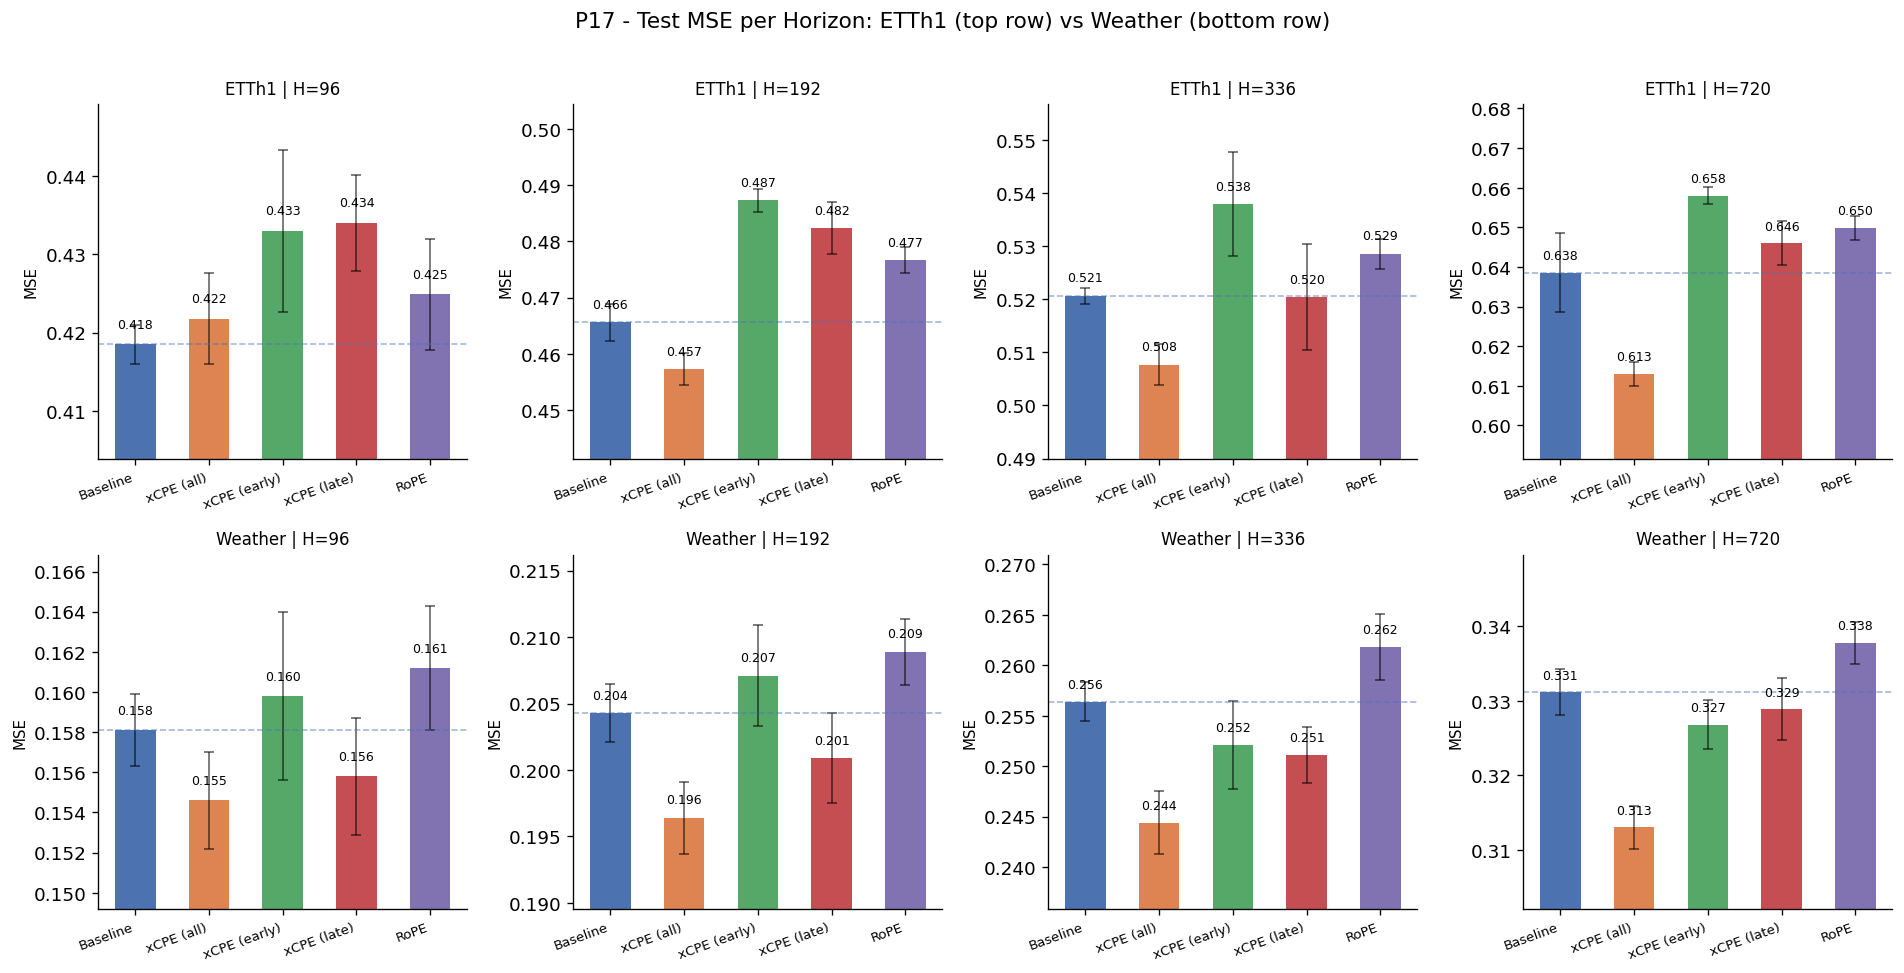

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
x      = np.arange(len(VARIANT_ORDER))
colors = [PALETTE[v] for v in VARIANT_ORDER]

for row_i, (dset, df) in enumerate(DATASETS.items()):
    for col_i, horizon in enumerate(HORIZONS):
        ax   = axes[row_i, col_i]
        hdf  = df[df['horizon'] == horizon].set_index('variant').reindex(VARIANT_ORDER)
        bump = hdf['mse_mean'].max() * 0.004
        bars = ax.bar(x, hdf['mse_mean'], yerr=hdf['mse_std'], capsize=3,
                      color=colors, width=0.55,
                      error_kw={'elinewidth': 1.0, 'ecolor': 'black', 'alpha': 0.6})
        for bar, val in zip(bars, hdf['mse_mean']):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bump,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
        ax.axhline(hdf.loc['baseline', 'mse_mean'], color=PALETTE['baseline'],
                   linestyle='--', linewidth=1.0, alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([DISPLAY[v] for v in VARIANT_ORDER],
                           rotation=20, ha='right', fontsize=8)
        ax.set_ylabel('MSE', fontsize=9)
        ax.set_title(f'{dset} | H={horizon}', fontsize=10)
        ax.set_ylim(hdf['mse_mean'].min() * 0.965, hdf['mse_mean'].max() * 1.035)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('P17 - Test MSE per Horizon: ETTh1 (top row) vs Weather (bottom row)',
             fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP17_per_horizon_grid.png', bbox_inches='tight')
plt.show()

### P18 — Absolute MSE Advantage over Baseline
`advantage = baseline_MSE - variant_MSE` (positive = better than baseline)

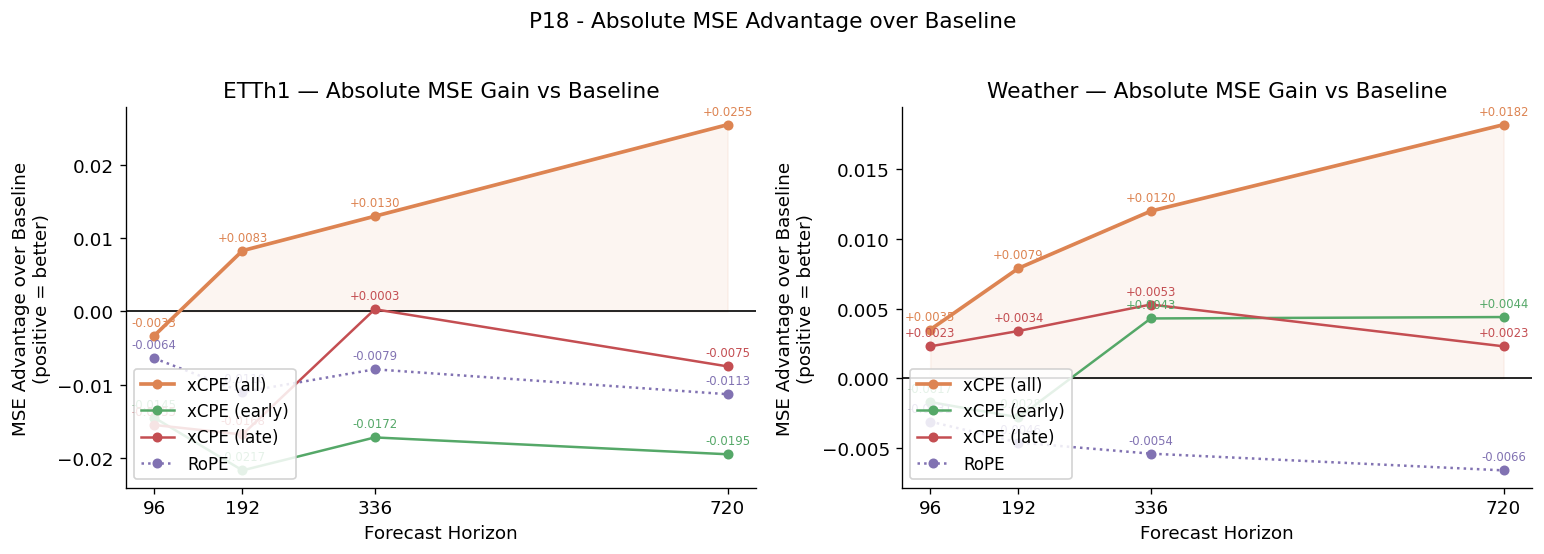

In [35]:
compare = ['xcpe_all', 'xcpe_early', 'xcpe_late', 'rope']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (dset, df) in zip(axes, DATASETS.items()):
    base_ser = df[df['variant'] == 'baseline'].set_index('horizon')['mse_mean']
    ax.axhline(0, color='black', linewidth=1.0)

    for variant in compare:
        vdf = df[df['variant'] == variant].sort_values('horizon')
        advantage = [base_ser[h] - vdf.set_index('horizon').loc[h, 'mse_mean']
                     for h in HORIZONS]
        ls = '-' if 'xcpe' in variant else ':'
        lw = 2.2 if variant == 'xcpe_all' else 1.5
        ax.plot(HORIZONS, advantage, marker='o', markersize=5,
                color=PALETTE[variant], linestyle=ls, linewidth=lw,
                label=DISPLAY[variant])
        for h, adv in zip(HORIZONS, advantage):
            ax.annotate(f'{adv:+.4f}', xy=(h, adv), xytext=(0, 6),
                        textcoords='offset points',
                        ha='center', fontsize=7, color=PALETTE[variant])

    xcpe_adv = [base_ser[h] - df[
                    (df['variant']=='xcpe_all') & (df['horizon']==h)
                ]['mse_mean'].values[0] for h in HORIZONS]
    ax.fill_between(HORIZONS, xcpe_adv, 0, where=[a > 0 for a in xcpe_adv],
                    alpha=0.08, color=PALETTE['xcpe_all'], interpolate=True)

    ax.set_xticks(HORIZONS)
    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel('MSE Advantage over Baseline\n(positive = better)')
    ax.set_title(f'{dset} — Absolute MSE Gain vs Baseline')
    ax.legend(loc='lower left', framealpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('P18 - Absolute MSE Advantage over Baseline', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP18_advantage_lines.png', bbox_inches='tight')
plt.show()

### P19 — Variant Rankings per Horizon (rank + MSE value per cell)

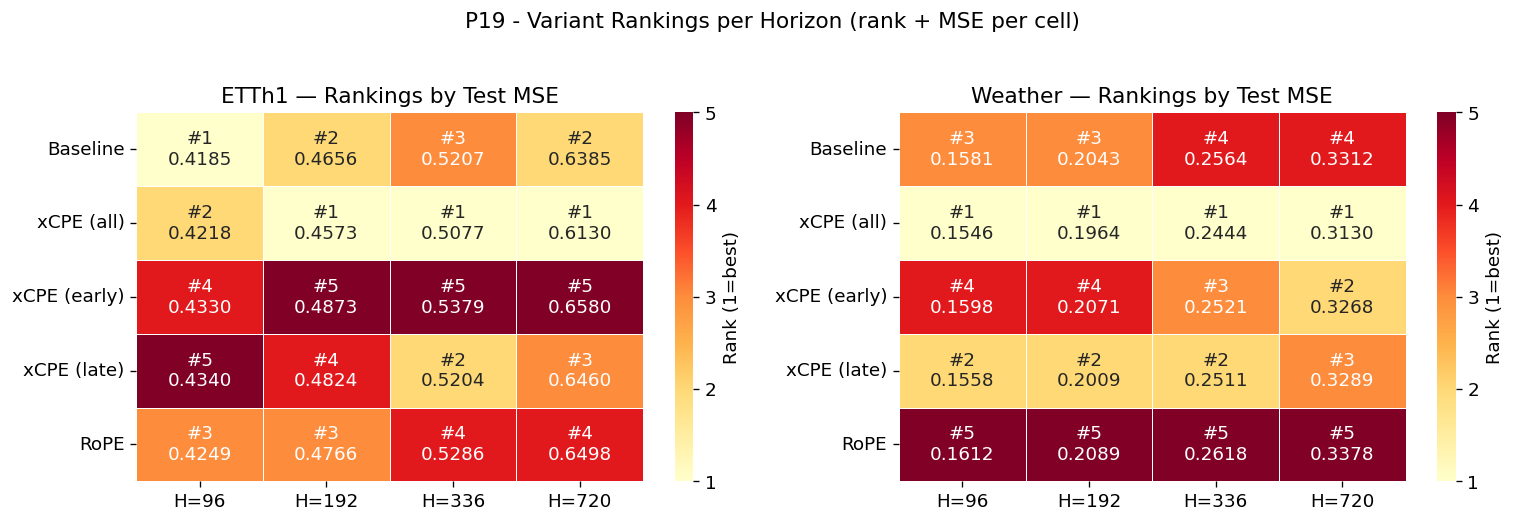

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, (dset, df) in zip(axes, DATASETS.items()):
    rank_rows = []
    for variant in VARIANT_ORDER:
        row = []
        for horizon in HORIZONS:
            hdf  = df[df['horizon'] == horizon].sort_values('mse_mean').reset_index(drop=True)
            rank = hdf[hdf['variant'] == variant].index[0] + 1
            row.append(rank)
        rank_rows.append(row)

    rank_df = pd.DataFrame(rank_rows,
                           index=[DISPLAY[v] for v in VARIANT_ORDER],
                           columns=[f'H={h}' for h in HORIZONS])

    annot = pd.DataFrame(index=rank_df.index, columns=rank_df.columns, dtype=object)
    for variant, dname in zip(VARIANT_ORDER, rank_df.index):
        for horizon, col in zip(HORIZONS, rank_df.columns):
            mse = df[(df['variant']==variant) & (df['horizon']==horizon)]['mse_mean'].values[0]
            annot.loc[dname, col] = f'#{rank_df.loc[dname, col]}\n{mse:.4f}'

    sns.heatmap(rank_df.astype(float), ax=ax, annot=annot, fmt='',
                cmap='YlOrRd', vmin=1, vmax=len(VARIANT_ORDER), linewidths=0.6,
                cbar_kws={'label': 'Rank (1=best)',
                          'ticks': list(range(1, len(VARIANT_ORDER)+1))})
    ax.set_title(f'{dset} — Rankings by Test MSE')
    ax.set_ylabel('')

fig.suptitle('P19 - Variant Rankings per Horizon (rank + MSE per cell)', fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'figP19_ranking_heatmap.png', bbox_inches='tight')
plt.show()

---
## Summary Tables — Full Results (MSE and MAE)

In [37]:
from IPython.display import display

for dset, df in DATASETS.items():
    print(f'\n{"="*60}')
    print(f'  {dset}')
    print(f'{"="*60}')
    pivot = df.pivot_table(index='variant', columns='horizon',
                           values=['mse_mean', 'mae_mean'])
    pivot = pivot.reindex(VARIANT_ORDER)
    pivot.index = [DISPLAY[v] for v in VARIANT_ORDER]
    display(pivot.round(4))


  ETTh1


mae_mean                         mse_mean                        
horizon           96      192     336     720      96      192     336     720
Baseline       0.4479  0.4828  0.5181  0.5948   0.4185  0.4656  0.5207  0.6385
xCPE (all)     0.4515  0.4741  0.5092  0.5787   0.4218  0.4573  0.5077  0.6130
xCPE (early)   0.4618  0.4986  0.5300  0.6039   0.4330  0.4873  0.5379  0.6580
xCPE (late)    0.4640  0.4971  0.5207  0.5997   0.4340  0.4824  0.5204  0.6460
RoPE           0.4573  0.4934  0.5285  0.6027   0.4249  0.4766  0.5286  0.6498


  Weather


mae_mean                         mse_mean                        
horizon           96      192     336     720      96      192     336     720
Baseline       0.2067  0.2498  0.2894  0.3469   0.1581  0.2043  0.2564  0.3312
xCPE (all)     0.2036  0.2435  0.2801  0.3337   0.1546  0.1964  0.2444  0.3130
xCPE (early)   0.2088  0.2527  0.2849  0.3425   0.1598  0.2071  0.2521  0.3268
xCPE (late)    0.2048  0.2462  0.2831  0.3447   0.1558  0.2009  0.2511  0.3289
RoPE           0.2103  0.2544  0.2946  0.3512   0.1612  0.2089  0.2618  0.3378